In [1]:
import pandas as pd
df = pd.read_csv("Admission.csv")

# check the data
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,Year
0,1,337,118,4,4.5,4.5,9.65,1,0.92,2022
1,2,324,107,4,4.0,4.5,8.87,1,0.76,2022
2,3,316,104,3,3.0,3.5,8.00,1,0.72,2022
3,4,322,110,3,3.5,2.5,8.67,1,0.80,2022
4,5,314,103,2,2.0,3.0,8.21,0,0.65,2022


In [2]:
# sort data according to year
df = df.sort_values("Year")
# reset the index
df = df.reset_index(drop=True)
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,Year
0,1,337,118,4,4.5,4.5,9.65,1,0.92,2022
1,128,319,112,3,2.5,2.0,8.71,1,0.78,2022
2,129,326,112,3,3.5,3.0,9.10,1,0.84,2022
3,130,333,118,5,5.0,5.0,9.35,1,0.92,2022
4,131,339,114,5,4.0,4.5,9.76,1,0.96,2022


In [3]:
# calculate 3 observation moving average of cgpa
df["cgpa_moving_avg"] = df["CGPA"].rolling(window=3).mean()

df[["Year", "CGPA", "cgpa_moving_avg"]].head(10)

,Year,CGPA,cgpa_moving_avg
0,2022,9.65,NaN
1,2022,8.71,NaN
2,2022,9.10,9.153333
3,2022,9.35,9.053333
4,2022,9.76,9.403333
5,2022,8.65,9.253333
6,2022,8.56,8.990000
7,2022,8.78,8.663333
8,2022,9.28,8.873333
9,2022,8.77,8.943333


In [4]:
# give more importance to recent cgpa values
df["cgpa_ewm"] = df["CGPA"].ewm(span=3, adjust=False).mean()

df[["Year", "CGPA", "cgpa_ewm"]].head(10)
#ewm is similar to moving average, but it gives more importance to recent values

,Year,CGPA,cgpa_ewm
0,2022,9.65,9.650000
1,2022,8.71,9.180000
2,2022,9.10,9.140000
3,2022,9.35,9.245000
4,2022,9.76,9.502500
5,2022,8.65,9.076250
6,2022,8.56,8.818125
7,2022,8.78,8.799063
8,2022,9.28,9.039531
9,2022,8.77,8.904766


In [5]:
# calculate rolling average of chance of admission
df["admit_rolling_mean"] = (
    df["Chance of Admit "].rolling(window=3).mean()
)

df[["Year", "Chance of Admit ", "admit_rolling_mean"]].head(10)
#this helps us see the general admission trend instead of looking at individual values.

,Year,Chance of Admit,admit_rolling_mean
0,2022,0.92,NaN
1,2022,0.78,NaN
2,2022,0.84,0.846667
3,2022,0.92,0.846667
4,2022,0.96,0.906667
5,2022,0.77,0.883333
6,2022,0.71,0.813333
7,2022,0.79,0.756667
8,2022,0.89,0.796667
9,2022,0.82,0.833333


In [6]:
# calculate rolling standard deviation of cgpa
#lowr STD = performance is more stable
#high STD = performance changes more
df["cgpa_rolling_std"] = df["CGPA"].rolling(window=3).std()

df[["Year", "CGPA", "cgpa_rolling_std"]].head(10)
#this is show applicant performance stability

,Year,CGPA,cgpa_rolling_std
0,2022,9.65,NaN
1,2022,8.71,NaN
2,2022,9.10,0.472264
3,2022,9.35,0.322542
4,2022,9.76,0.333217
5,2022,8.65,0.561278
6,2022,8.56,0.668356
7,2022,8.78,0.110604
8,2022,9.28,0.368963
9,2022,8.77,0.291605


In [7]:
# create features for other important columns
# gre moving average
df["gre_moving_avg"] = df["GRE Score"].rolling(window=3).mean()

# toefl moving average
df["toefl_moving_avg"] = df["TOEFL Score"].rolling(window=3).mean()

# gre ewm
df["gre_ewm"] = df["GRE Score"].ewm(span=3, adjust=False).mean()

# toefl ewm
df["toefl_ewm"] = df["TOEFL Score"].ewm(span=3, adjust=False).mean()

In [8]:
#the first few rows contain nan because there are not enough previous observations to calculate a window of 3.
df = df.dropna()

df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,Year,cgpa_moving_avg,cgpa_ewm,admit_rolling_mean,cgpa_rolling_std,gre_moving_avg,toefl_moving_avg,gre_ewm,toefl_ewm
2,129,326,112,3,3.5,3.0,9.10,1,0.84,2022,9.153333,9.140000,0.846667,0.472264,327.333333,114.000000,327.000,113.50000
3,130,333,118,5,5.0,5.0,9.35,1,0.92,2022,9.053333,9.245000,0.846667,0.322542,326.000000,114.000000,330.000,115.75000
4,131,339,114,5,4.0,4.5,9.76,1,0.96,2022,9.403333,9.502500,0.906667,0.333217,332.666667,114.666667,334.500,114.87500
5,132,303,105,5,5.0,4.5,8.65,0,0.77,2022,9.253333,9.076250,0.883333,0.561278,325.000000,112.333333,318.750,109.93750
6,133,309,105,5,3.5,3.5,8.56,0,0.71,2022,8.990000,8.818125,0.813333,0.668356,317.000000,108.000000,313.875,107.46875


In [9]:
df[
    [
        "Year",
        "CGPA",
        "cgpa_moving_avg",
        "cgpa_ewm",
        "cgpa_rolling_std",
        "GRE Score",
        "gre_moving_avg",
        "gre_ewm"
    ]
].head(10)
# this are the new feature

,Year,CGPA,cgpa_moving_avg,cgpa_ewm,cgpa_rolling_std,GRE Score,gre_moving_avg,gre_ewm
2,2022,9.10,9.153333,9.140000,0.472264,326,327.333333,327.000000
3,2022,9.35,9.053333,9.245000,0.322542,333,326.000000,330.000000
4,2022,9.76,9.403333,9.502500,0.333217,339,332.666667,334.500000
5,2022,8.65,9.253333,9.076250,0.561278,303,325.000000,318.750000
6,2022,8.56,8.990000,8.818125,0.668356,309,317.000000,313.875000
7,2022,8.78,8.663333,8.799063,0.110604,323,311.666667,318.437500
8,2022,9.28,8.873333,9.039531,0.368963,333,321.666667,325.718750
9,2022,8.77,8.943333,8.904766,0.291605,314,323.333333,319.859375
10,2022,8.45,8.833333,8.677383,0.418609,312,319.666667,315.929688
11,2022,8.16,8.460000,8.418691,0.305123,316,314.000000,315.964844


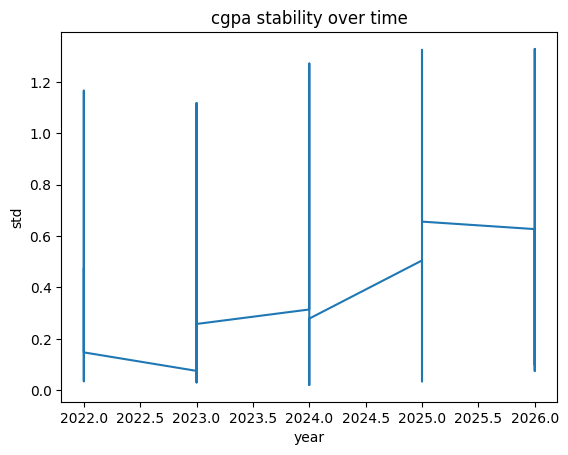

In [12]:
plt.plot(df["Year"], df["cgpa_rolling_std"])

plt.xlabel("year")
plt.ylabel("std")
plt.title("cgpa stability over time")
plt.show()

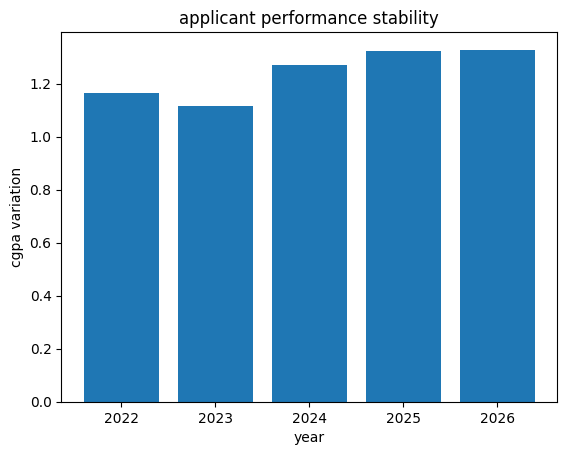

In [13]:
plt.bar(df["Year"], df["cgpa_rolling_std"])

plt.xlabel("year")
plt.ylabel("cgpa variation")
plt.title("applicant performance stability")

plt.show()